In [1]:
import pyemu
import os
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import shutil
import numpy as np
import sys

In [2]:
from swatmf import analyzer

# 01. Set working directory

In [3]:
# path to project directory
prj_dir = "C:\\Users\\seonggpa\\Documents\\projects\\watersheds\\hbasnet_opt"
main_opt_path = os.path.join(prj_dir, 'main_opt')
os.chdir(main_opt_path)

# 04. Run IES

## 04.1 Set up IES

In [4]:
# check number of cores on your computer
num_workers = psutil.cpu_count(logical=False)

In [5]:
pst_file = 'mb_pp_rw_prior.pst'

In [6]:
pst_ies = pyemu.Pst(f"{pst_file}")
# set IES
pst_ies.pestpp_options['ies_num_reals'] = 300 # number of realization
pst_ies.control_data.noptmax = 5 # number of iteration
pst_ies.write(f"{pst_file.replace('_prior.pst', '_ies.pst')}", version=2) # write new IES control file

noptmax:5, npar_adj:83, nnz_obs:5114


In [7]:
os.chdir(prj_dir)

In [8]:
os.getcwd()

'C:\\Users\\seonggpa\\Documents\\projects\\watersheds\\hbasnet_opt'

In [9]:
m_d = os.path.join(prj_dir, "mb_pp_rw_ies01")

## 04.2 Execute

In [ ]:
pyemu.os_utils.start_workers(main_opt_path, # the folder which contains the "template" PEST dataset
                            'pestpp-ies', #the PEST software version we want to run
                            'mb_pp_rw_ies.pst', # the control file to use with PEST
                            num_workers=num_workers, #how many agents to deploy
                            worker_root='.', #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d, #the manager directory,
                            # reuse_master=True
                            )

# 05. Analyze results
## 05.1 Check model performance

In [10]:
pst = pyemu.Pst(os.path.join(m_d,'mb_pp_rw_ies.pst')) # load control file

In [11]:
# load prior simulation
pr_oe = pyemu.ObservationEnsemble.from_csv(
    pst=pst,filename=os.path.join(m_d,"mb_pp_rw_ies.0.obs.csv")
    )
# load posterior simulation
pt_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,"mb_pp_rw_ies.{0}.obs.csv".format(pst.control_data.noptmax)))


<Figure size 800x1050 with 0 Axes>

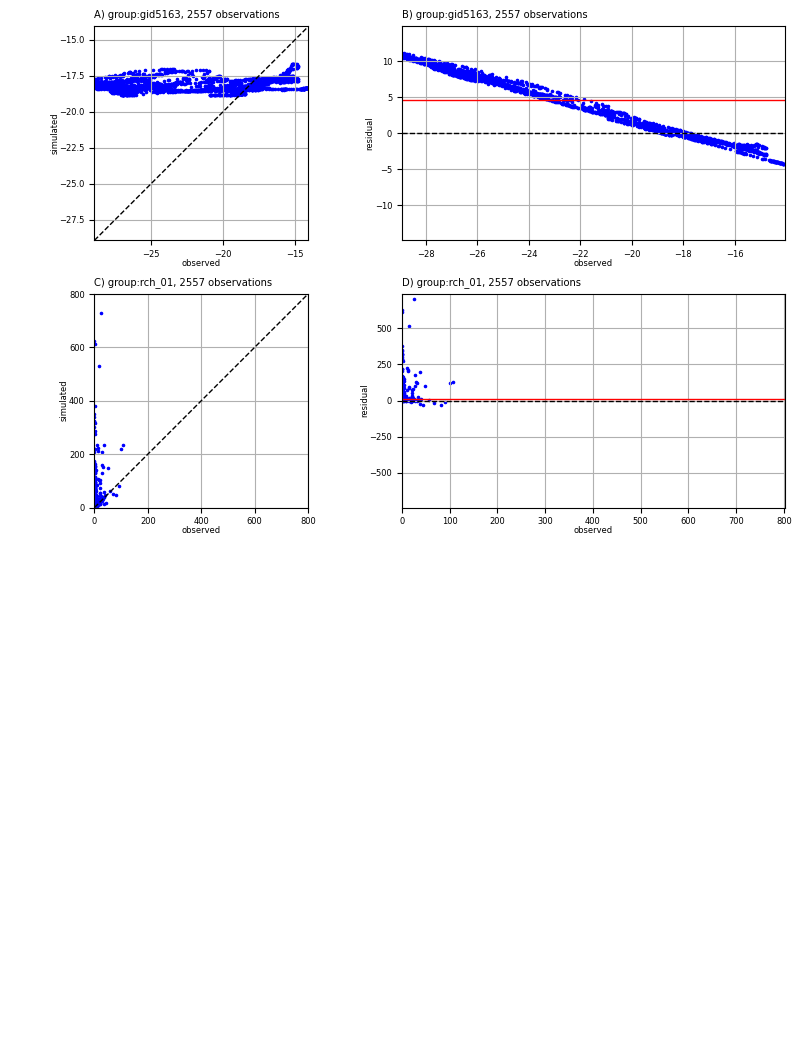

In [12]:
# plot 1 to 1 scatter plot and residuals
pyemu.plot_utils.res_1to1(pst);

In [13]:
# check phi values
pt_oe.phi_vector

real_name
0       7556.511573
1       8408.142881
2       7120.904750
3       8042.236020
4       7896.678137
           ...     
295     7878.657863
296     7689.576574
297     7959.610144
298     7923.517295
base    7854.001079
Length: 290, dtype: float64

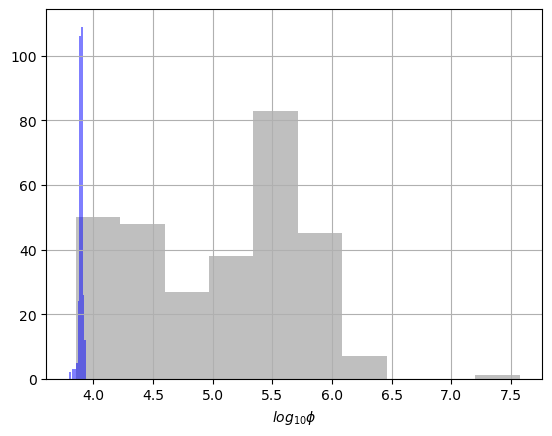

In [14]:
# plot progress
fig,ax = plt.subplots(1,1)
pr_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="0.5",ec="none",alpha=0.5,density=False)
pt_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="b",ec="none",alpha=0.5,density=False)
_ = ax.set_xlabel("$log_{10}\\phi$")
plt.show()


## 05.2 Prior and Posterior parameter probability

In [15]:
pr_pe = pyemu.ParameterEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,"mb_pp_rw_ies.{0}.par.csv".format(0)))
pt_pe = pyemu.ParameterEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,"mb_pp_rw_ies.{0}.par.csv".format(pst.control_data.noptmax)))

In [16]:
df_pars = pd.read_csv(os.path.join(m_d, "mb_pp_rw_ies.par_data.csv"))
sel_pars = df_pars.loc[df_pars["partrans"]=='log']
sel_pars

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,i,j,zone
0,adj_pkr,log,factor,1.00,0.1000,1.9,swat,1.0,-1.0,1,NaN,NaN,NaN
1,c_factor,log,factor,1.00,0.1000,1.9,swat,1.0,-1.0,1,NaN,NaN,NaN
2,canmx,log,factor,1.00,0.1000,1.9,swat,1.0,-1.0,1,NaN,NaN,NaN
3,ch_k1,log,factor,1.00,0.1000,1.9,swat,1.0,-1.0,1,NaN,NaN,NaN
4,ch_n1,log,factor,1.00,0.1000,1.9,swat,1.0,-1.0,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,sy0_i:65_j:55_zone:1,log,factor,0.01,0.0001,0.6,sy,1.0,0.0,1,65.0,55.0,1.0
110,sy0_i:75_j:55_zone:1,log,factor,0.01,0.0001,0.6,sy,1.0,0.0,1,75.0,55.0,1.0
111,sy0_i:85_j:45_zone:1,log,factor,0.01,0.0001,0.6,sy,1.0,0.0,1,85.0,45.0,1.0
112,sy0_i:85_j:55_zone:1,log,factor,0.01,0.0001,0.6,sy,1.0,0.0,1,85.0,55.0,1.0


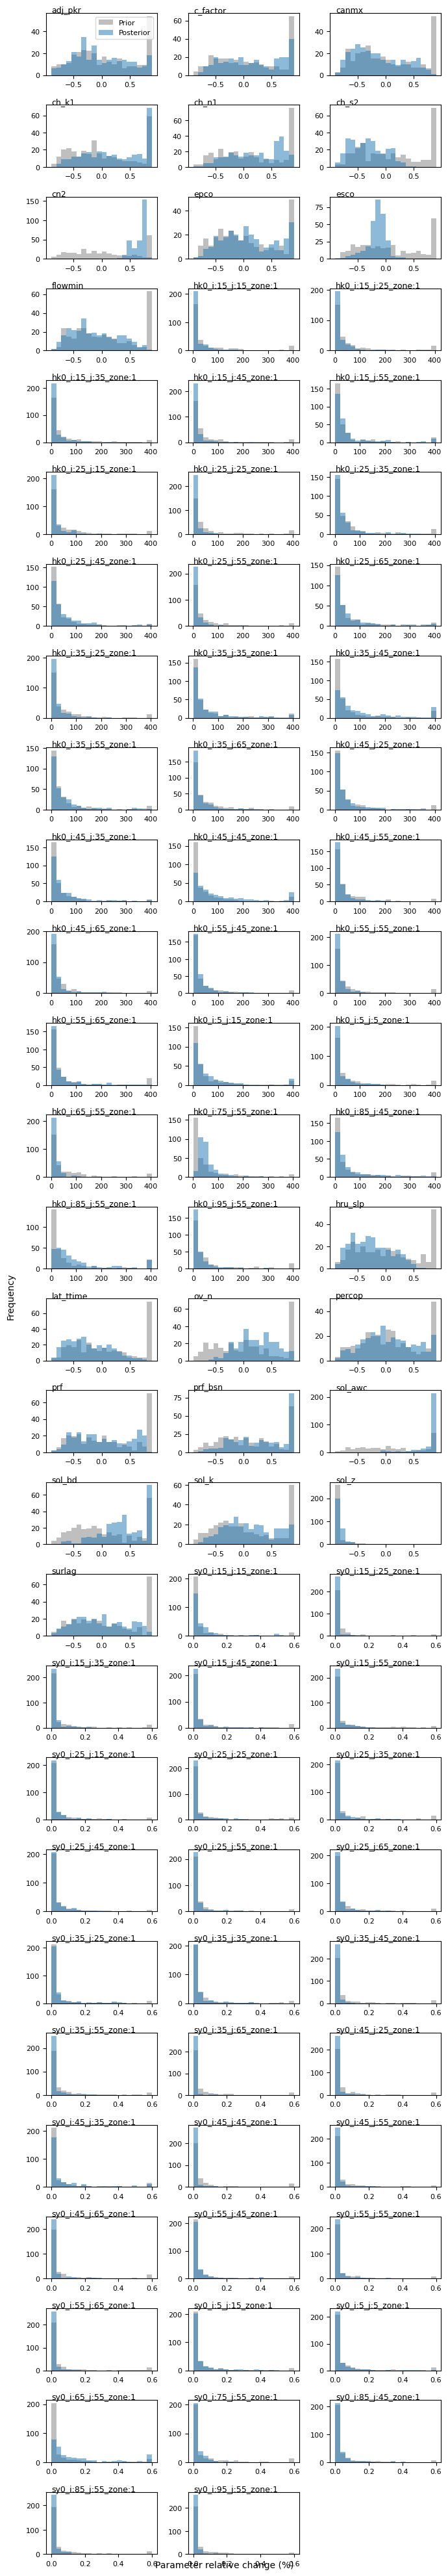

(<Figure size 700x4000 with 84 Axes>,
 array([[<Axes: title={'left': 'adj_pkr'}>,
         <Axes: title={'left': 'c_factor'}>,
         <Axes: title={'left': 'canmx'}>],
        [<Axes: title={'left': 'ch_k1'}>, <Axes: title={'left': 'ch_n1'}>,
         <Axes: title={'left': 'ch_s2'}>],
        [<Axes: title={'left': 'cn2'}>, <Axes: title={'left': 'epco'}>,
         <Axes: title={'left': 'esco'}>],
        [<Axes: title={'left': 'flowmin'}>,
         <Axes: title={'left': 'hk0_i:15_j:15_zone:1'}>,
         <Axes: title={'left': 'hk0_i:15_j:25_zone:1'}>],
        [<Axes: title={'left': 'hk0_i:15_j:35_zone:1'}>,
         <Axes: title={'left': 'hk0_i:15_j:45_zone:1'}>,
         <Axes: title={'left': 'hk0_i:15_j:55_zone:1'}>],
        [<Axes: title={'left': 'hk0_i:25_j:15_zone:1'}>,
         <Axes: title={'left': 'hk0_i:25_j:25_zone:1'}>,
         <Axes: title={'left': 'hk0_i:25_j:35_zone:1'}>],
        [<Axes: title={'left': 'hk0_i:25_j:45_zone:1'}>,
         <Axes: title={'left': 'hk0_i:

In [17]:
analyzer.plot_parameter_ensemble(
    pst, pr_pe=pr_pe, pt_pe=pt_pe, show=True, height=40, sel_pars=sel_pars
    )

## 05.3 Predictive Uncertainty

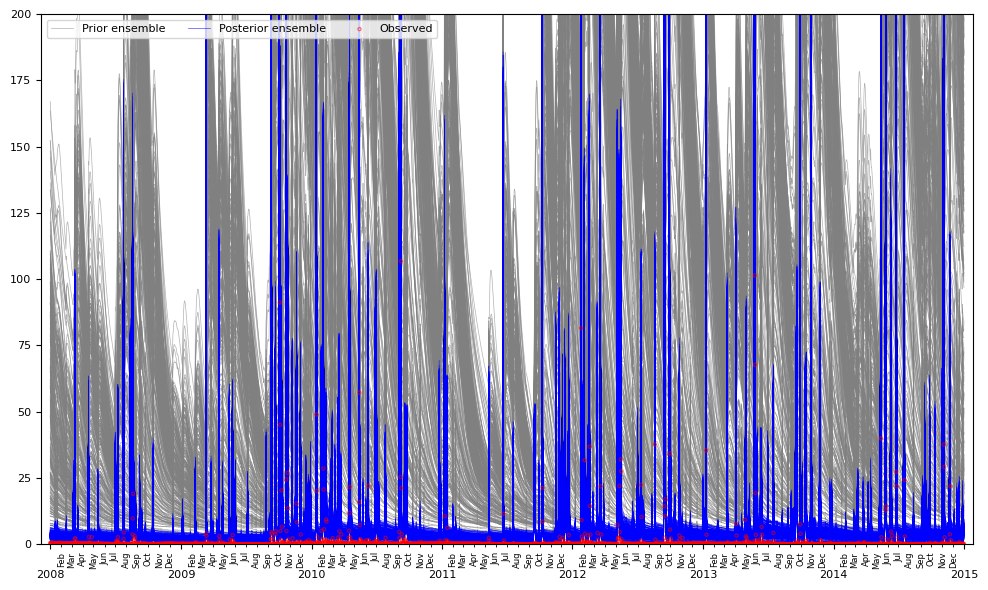

(<Figure size 1000x600 with 1 Axes>, <Axes: >)

In [18]:
analyzer.ua.plot_tseries_ensemble(
    pst, 'rch_01', pr_oe=pr_oe, pt_oe=pt_oe, height=6, dot=False, ymin=0, ymax=200, show=True)

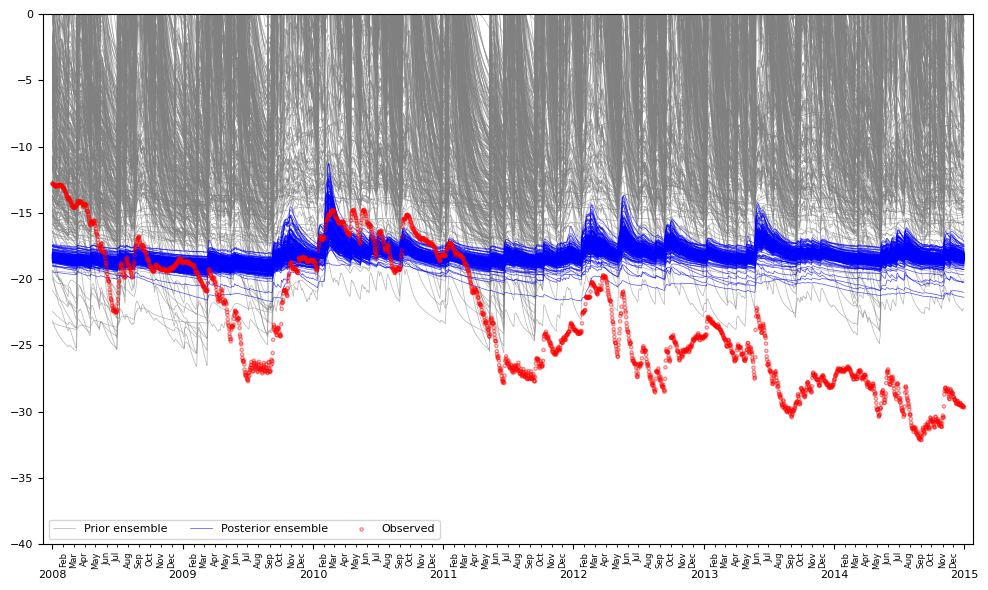

(<Figure size 1000x600 with 1 Axes>, <Axes: >)

In [22]:
analyzer.ua.plot_tseries_ensemble(
    pst, 'gid5163', pr_oe=pr_oe, pt_oe=pt_oe, height=6, dot=False, ymin=-40, ymax=0, show=True)

# 06. updates the model input files with parameter values

In [ ]:
os.getcwd()

In [ ]:
pst.parrep(parfile=os.path.join(m_d, "mb_pp_rw_ies.{0}.base.csv".format(pst.control_data.noptmax)))

In [ ]:
# updates the model input files with parameter values
pst.write_input_files(pst_path=m_d)

In [ ]:
# run the model forward run; this applies all the SWAT and MODFLOW paarameters, executes SWAT-MODFLOW 
os.chdir(m_d)
pyemu.os_utils.run('python forward_run.py')